# Frontier: PLAN 08 Step 13 actual high-escaping charts

This notebook isolates the part of Step 13 that is **still not constructed** after the overlap-comparison theorem was formalized.

The comparison frontier is now recorded separately in `notebooks/plan08_step13_overlap_comparison_frontier.ipynb`. The present notebook focuses on the remaining geometric-analytic task: build the **actual high-escaping chart chains** and package them into the Step 13 wrappers.


## What is already done versus what remains

Already formalized:

- the canonical arbitrarily-high escaping chains,
- the abstract uniqueness/comparison theorem for logarithm branches on connected chart chains,
- the high-level wrapper interfaces
  `HighEscapingActualChartChainsEventuallyEqAtOverlapsData`,
  `HighEscapingActualChartChainsLocalLogsRestrictGlobalData`, and
  `HighEscapingActualChartChainsProductComparisonData`.

Still missing:

1. for each basin loop `\gamma` and requested lower level `N_0`, choose a high escaping level `K = \mathrm{levelAbove}(\gamma, N_0)`;
2. construct the **actual** finite chart chain covering the curve
   $$
   A_K(t) = \Phi_\infty\bigl(f^{K}(\gamma(t))\bigr);
   $$
3. place on each chart the actual local logarithm branch coming from the pullback/root construction;
4. prove the neighboring actual branches agree on overlap neighborhoods, or prove the stronger statement that they all restrict from one global zero-free logarithm branch.


## What “construct the actual high-escaping charts” means

For each pair `(\gamma, K)` in the high-escaping regime, the missing object is not just a statement that some product is `1`. It is a concrete finite package:

- simply connected zero-free charts `U_0, \dots, U_m \subset \mathbf{C} \setminus \{0\}`;
- a subdivision `0 = t_0 < t_1 < \dots < t_{m+1} = 1` such that
  $$A_K([t_i,t_{i+1}]) \subset U_i;$$
- overlap points with `U_i \cap U_{i+1} \neq \varnothing`;
- on each `U_i`, the **actual** holomorphic logarithm branch attached to the pullback root problem;
- proofs that consecutive branches match near the chosen overlap points.

This is what will eventually populate
`HighEscapingActualChartChainsEventuallyEqAtOverlapsData`.

The word **actual** means that these charts and branches come from the real pullback construction we need for the basin-extension theorem, not from the already-available canonical one-chart model at high escaping levels.


## Numerical toy model of a high-escaping chart cover

We illustrate the geometry with
$$
f(z) = z^2 + 2, \qquad \gamma(t) = \tfrac{1}{2} e^{2\pi i t}, \qquad A_2(z) = f^2(z) = z^4 + 4 z^2 + 6.
$$

For this loop, the image curve `A_2(\gamma(t))` sits far to the right of the origin. This is the easy model of the high-escaping regime: one can cover the image by overlapping zero-free disks and use the principal logarithm on each disk.


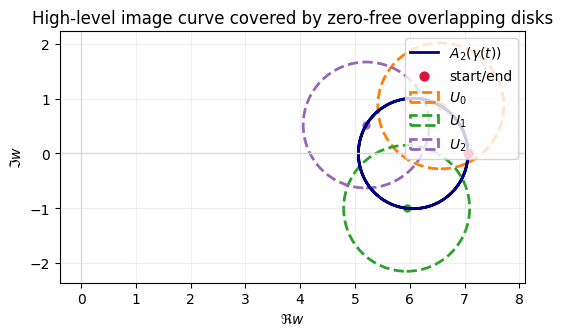

Minimum real part along the curve: 5.06250579745591
Minimum modulus along the curve: 5.062506966485313


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle


def gamma(t, r=0.5):
    return r * np.exp(2j * np.pi * t)


def A2(z):
    return z**4 + 4*z**2 + 6


ts = np.linspace(0.0, 1.0, 800)
zs = gamma(ts)
ws = A2(zs)

sample_idx = [60, 300, 560]
centers = ws[sample_idx]
radius = 1.15

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot(ws.real, ws.imag, color='navy', lw=2, label=r'$A_2(\gamma(t))$')
ax.scatter([ws[0].real], [ws[0].imag], color='crimson', s=40, zorder=3, label='start/end')
for k, c in enumerate(centers):
    disk = Circle((c.real, c.imag), radius, fill=False, ls='--', lw=2,
                  color=['tab:orange', 'tab:green', 'tab:purple'][k],
                  label=fr'$U_{k}$')
    ax.add_patch(disk)
    ax.scatter([c.real], [c.imag], color=disk.get_edgecolor(), s=25)
ax.axhline(0.0, color='0.85', lw=1)
ax.axvline(0.0, color='0.85', lw=1)
ax.set_aspect('equal', adjustable='box')
ax.set_title(r'High-level image curve covered by zero-free overlapping disks')
ax.set_xlabel(r'$\Re w$')
ax.set_ylabel(r'$\Im w$')
ax.legend(loc='upper right')
ax.grid(alpha=0.2)
plt.show()

print('Minimum real part along the curve:', ws.real.min())
print('Minimum modulus along the curve:', np.abs(ws).min())


The figure shows the kind of object Step 13 still has to build abstractly:

- a finite cover of the high-level image curve by zero-free charts,
- enough overlap between consecutive charts to continue one branch to the next,
- explicit control that the whole construction stays away from `0`.

In this toy example, the whole cover lies in the right half-plane, so the principal logarithm already gives a common global branch. In the real theorem, the point is to construct the corresponding branch data for the **actual** pullback charts associated to the loop.


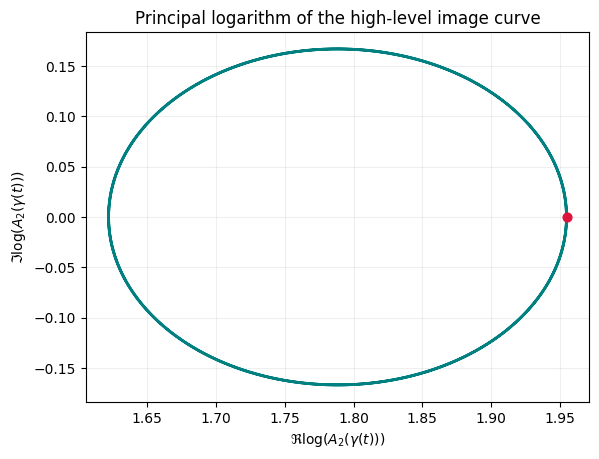

Endpoint mismatch for the principal log: 7.803059251204375e-17


In [2]:
log_ws = np.log(ws)

fig, ax = plt.subplots(figsize=(6.5, 4.8))
ax.plot(log_ws.real, log_ws.imag, color='teal', lw=2)
ax.scatter([log_ws[0].real], [log_ws[0].imag], color='crimson', s=40, zorder=3)
ax.set_title(r'Principal logarithm of the high-level image curve')
ax.set_xlabel(r'$\Re \log(A_2(\gamma(t)))$')
ax.set_ylabel(r'$\Im \log(A_2(\gamma(t)))$')
ax.grid(alpha=0.2)
plt.show()

print('Endpoint mismatch for the principal log:', abs(log_ws[0] - log_ws[-1]))


This log-plane picture is the positive model for the stronger wrapper
`HighEscapingActualChartChainsLocalLogsRestrictGlobalData`:

- one global zero-free logarithm branch exists on a neighborhood containing the whole curve,
- each local chart branch is a restriction of that global branch,
- therefore the overlap equalities are automatic.

The missing theorem is to realize this picture for the **actual** high-escaping pullback branches, not just for a toy right-half-plane example.


## Lean target isolated by this notebook

The remaining Step 13 work is to produce one of the following packages for the real `c = 2` high-escaping chains:

```lean
HighEscapingActualChartChainsEventuallyEqAtOverlapsData
HighEscapingActualChartChainsLocalLogsRestrictGlobalData
```

That means proving, for each loop and requested lower level, that the actual high-level chain can be chosen and that its local logarithm branches satisfy the overlap compatibility hypotheses already consumed by the formalized comparison theorem.

So this frontier notebook isolates an **existence-and-packaging problem**:
construct the actual charts, the actual branches on them, and the proofs that these branches fit together.
